In [1]:
import sys
import json
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from method import calculate_rel_distance_reference_point_cloud, calculate_distance_reference_point_cloud, clean_lidar_df, extract_new_whitwater_points, plot_evaluation

sns.set_theme(style="ticks")
warnings.filterwarnings("ignore")

Load data

In [2]:
# load point cloud data
las_df = pd.read_csv("data\pielach.txt", index_col=0)

# filter point clould data to whitewater area of interest
whitewater_df = pd.read_csv("data\pielach_whitewater.txt", index_col=0)

# load waveform data from json
waveform_data_df = pd.read_json("data/waveform_data.json")

# load reference data
ref_local_coordinates_df = pd.read_csv("data/all_reference.txt", index_col=0)

In [3]:
# get point data
lidar_coordinates = whitewater_df[["x", "y", "z"]].values
reference_coordinates = ref_local_coordinates_df[["x", "y", "z"]].values

# get socs and direction vectors
socs_coordinates = whitewater_df[["xyz_socs[0]", "xyz_socs[1]", "xyz_socs[2]"]].values
direction_vector = whitewater_df[["direction[0]", "direction[1]", "direction[2]"]].values

# get waveform data
waveform_data = waveform_data_df["wfm"].values

# adjust sensor coordinates to meter values for plotting
x_offset = np.abs(min(las_df["x"].values))
y_offset = np.abs(min(las_df["y"].values))

Plot area of interest

Text(0, 1.05, 'A')

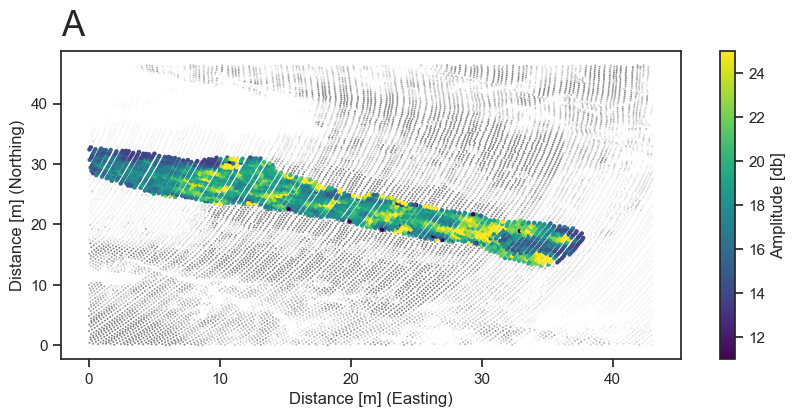

In [4]:
sns.set(rc={'figure.figsize':(10, 4)})
sns.set_theme(style="ticks")


# plot area of interest
ax = sns.scatterplot(x=las_df["x"].values + x_offset, y=las_df["y"].values + y_offset, 
                     hue=las_df["amplitude"], hue_norm=(11, 25), palette="Grays", legend=False, linewidth=0, s=2, alpha=0.5)

# plot whitewater section
ax = sns.scatterplot(x=whitewater_df["x"].values + x_offset, y=whitewater_df["y"].values + y_offset, 
                     hue=whitewater_df["amplitude"], hue_norm=(11, 25), palette="viridis", legend=False, linewidth=0, s=10)


# add a colorbar
cbar = ax.figure.colorbar(plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(11, 25)), ax=ax)

# add labels
cbar.set_label("Amplitude [db]")
ax.set_xlabel("Distance [m] (Easting)")
ax.set_ylabel("Distance [m] (Northing)")
ax.text(0, 1.05, "A", fontsize=25, transform=ax.transAxes)

In [5]:
# whitewater parameters
range_gate = 1
sample_intervals = 5.025e-10
refraction_coefficient = 1.335

# get new whitewater points
df_new_points = extract_new_whitwater_points(whitewater_df, waveform_data, socs_coordinates, direction_vector, sample_intervals, range_gate, refraction_coefficient)

# filter points through clustering
filtered_new_points = clean_lidar_df(df_new_points, epsilon=0.9, outlier_or_max_cluster="outlier").values

Text(0, 1.05, 'B')

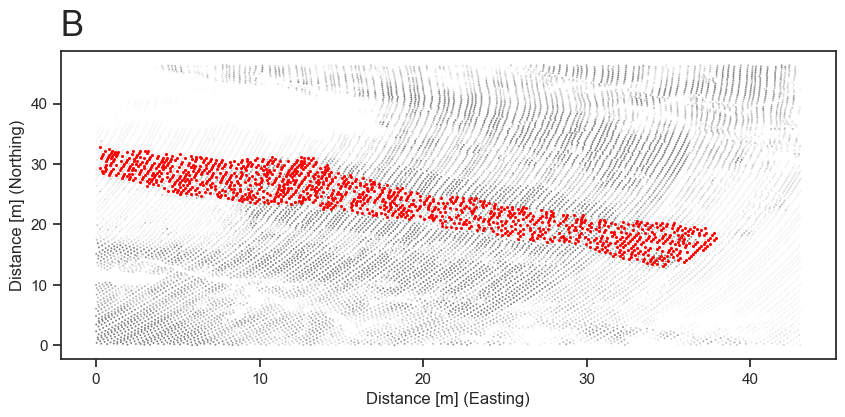

In [6]:
sns.set(rc={'figure.figsize':(10, 4)})
sns.set_theme(style="ticks")


# plot dataset projection with curve width for color
ax = sns.scatterplot(x=las_df["x"].values + x_offset, y=las_df["y"].values + y_offset, 
                     hue=las_df["amplitude"], hue_norm=(11, 25), palette="Grays", legend=False, linewidth=0, s=2, alpha=0.5)

ax = sns.scatterplot(x=filtered_new_points.T[0] + x_offset, y=filtered_new_points.T[1] + y_offset, linewidth=0, color="red", s=5, legend=False)


# add labels
cbar.set_label("Amplitude [db]")
ax.set_xlabel("Distance [m] (Easting)")
ax.set_ylabel("Distance [m] (Northing)")
ax.text(0, 1.05, "B", fontsize=25, transform=ax.transAxes)

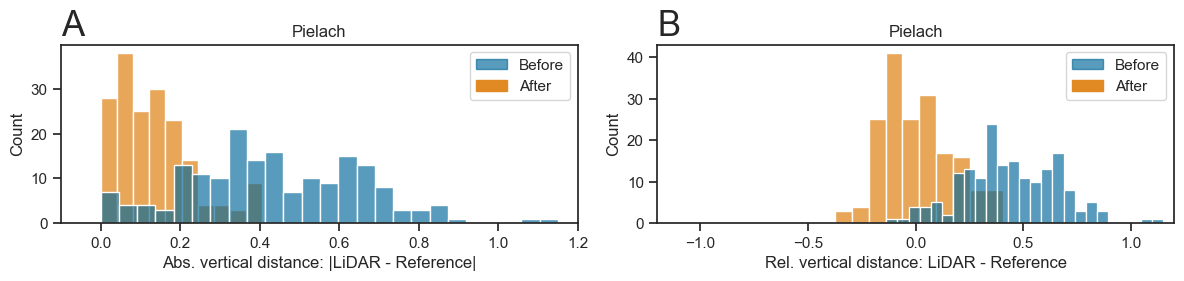

In [7]:
sns.set(font_scale=1, style="ticks")
plt.figure(figsize=(12, 3))

# get coordinates 
whitewater_coordinates = whitewater_df[["x", "y", "z"]].values
old_and_new_coordinates = np.array(list(whitewater_coordinates) + list(filtered_new_points))


plt.subplot(1, 2, 1)

# get absolute vertical distances
distances_before = (calculate_distance_reference_point_cloud(reference_coordinates, whitewater_coordinates))
distances_after = (calculate_distance_reference_point_cloud(reference_coordinates, old_and_new_coordinates))

# plot histogram
plot_evaluation(distances_before, distances_after, (-0.1, 1.2), "Abs. vertical distance: |LiDAR - Reference|", "A")


plt.subplot(1, 2, 2)

# get relative vertical distances
distances_before = (calculate_rel_distance_reference_point_cloud(reference_coordinates, whitewater_coordinates))
distances_after = (calculate_rel_distance_reference_point_cloud(reference_coordinates, old_and_new_coordinates))

# plot histogram
plot_evaluation(distances_before, distances_after, (-1.2, 1.2), "Rel. vertical distance: LiDAR - Reference", "B")


plt.tight_layout()